# ForceGNN Usage Example

This notebook demonstrates how to use the refactored `GNN_inference` module step-by-step.


In [51]:
# Import everything from the module
import sys
sys.path.append('..')

import importlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
clrs = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']

## Step 1: Load and Prepare Data


In [52]:
# parameters
datatype = "MDCK" # "EMT" or "Peptide" or "MDCK"
r_cut = 100 #sensible cutoff value for pairwise forces
Dynamics = "UD" # "UD" or "OD_Persistent"
Derivative = "Naive" # "Naive" or "Weak"
datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/SeanData/Data_CSVs/"
dt = 0.167
tau = None #None if Naive or even number if Weak
max_frames = 200 
# neighbourhood parameters
useNeighborList = True
n_boxes=8
neighbor_rebuild_interval=5
neighbor_domain_margin=3
#training parameters
hiddenDs = 64
Epochs = 100
#save model
datasave = '//Users/billiemeadowcroft/Dropbox/PostDocCode/GNN/My_GNN/WorkingVersion/SeanDataGNN/FairComparison_UD_Persistent/models/'

#-------- Checks ---------------#

if tau is None:
    if Derivative == "Weak":
        raise ValueError("tau is None and Derivative is Weak")

print("Loading source code...")

if Dynamics == "UD":
    import FairComparison_UD_Persistent.GNN_inference_UD
    importlib.reload(FairComparison_UD_Persistent.GNN_inference_UD)
    from FairComparison_UD_Persistent.GNN_inference_UD import *
elif Dynamics == "OD_Persistent":
    import FairComparison_UD_Persistent.GNN_inference_OD_Persistent
    importlib.reload(FairComparison_UD_Persistent.GNN_inference_OD_Persistent)
    from FairComparison_UD_Persistent.GNN_inference_OD_Persistent import *
else:
    raise ValueError("Invalid Dynamics must be UD or OD")

print("Loading data...")
# ------------  Load data ---------------#
if datatype == "EMT":
    dataname = "treatment_control_edges_OG_All.csv"
elif datatype == "Peptide":
    dataname = "treatment_control_edges_Att_offset49_All_BadTracksTrunc.csv"
elif datatype == "MDCK":
    dataname = '20260130_sparse_position1.csv'
else:
    raise ValueError("Invalid datatype must be EMT or Peptide")
data = load_data(datadir, dataname)

# ------------ Calculate derivatives (velocities and accelerations) ---------------#

T_weak = False
T_Naive = False

if Derivative == "Weak":
    T_weak = True
    print("Using Weak Derivative")
elif Derivative == "Naive":
    T_Naive = True
    print("Using Naïve Derivative")
else:
    raise ValueError("Invalid Derivative must be Weak or Naive")
print("Calculating Derivatives...")
data_clean = calculate_derivatives(data, dt=dt,weak_form = T_weak,naive_form = T_Naive,tau = tau)


# ------------- Prepare dataset ---------------#
print("Preparing dataset...")
dataset = prepare_dataset(data_clean,cutoff=r_cut,max_frames=max_frames,use_neighbor_list=useNeighborList,n_boxes=n_boxes,neighbor_rebuild_interval=neighbor_rebuild_interval,neighbor_domain_margin=neighbor_domain_margin)

print("Splitting dataset...")

train_frac = 0.7
val_frac = 0.15
test_frac = 0.15
train_data, val_data, test_data, dataALL = split_dataset(dataset, train_frac = train_frac,val_frac=val_frac)


Loading source code...
Loading data...
Data loaded: (94919, 6)
Columns: ['Unnamed: 0', 'frame', 'particle', 'x', 'y', 'z']
Number of frames: 145
Using Naïve Derivative
Calculating Derivatives...
Calculating derivatives...
Processing 1519 particles...
Calculating naïve derivatives...
Acceleration statistics:
  ax: mean=0.428, std=66.087
  ay: mean=0.211, std=67.739
Preparing dataset...
Preparing dataset from 145 frames...
processing frame  0.0
processing frame  1.0
processing frame  2.0
processing frame  3.0
processing frame  4.0
processing frame  5.0
processing frame  6.0
processing frame  7.0
processing frame  8.0
processing frame  9.0
processing frame  10.0
processing frame  11.0
processing frame  12.0
processing frame  13.0
processing frame  14.0
processing frame  15.0
processing frame  16.0
processing frame  17.0
processing frame  18.0
processing frame  19.0
processing frame  20.0
processing frame  21.0
processing frame  22.0
processing frame  23.0
processing frame  24.0
processing

In [62]:
Dynamics = "OD_Persistent"

if Dynamics == "UD":
    import FairComparison_UD_Persistent.GNN_inference_UD
    importlib.reload(FairComparison_UD_Persistent.GNN_inference_UD)
    from FairComparison_UD_Persistent.GNN_inference_UD import *
elif Dynamics == "OD_Persistent":
    import FairComparison_UD_Persistent.GNN_inference_OD_Persistent
    importlib.reload(FairComparison_UD_Persistent.GNN_inference_OD_Persistent)
    from FairComparison_UD_Persistent.GNN_inference_OD_Persistent import *
else:
    raise ValueError("Invalid Dynamics must be UD or OD")

In [64]:
print("Creating model...")
tau_mem0 = 0.45
# Create model
if Dynamics == "UD":
    model = create_model(hidden_dim=64,gamma_init=-0.4)
else:
     model = create_model(hidden_dim=64,tau_init=tau_mem0)

print("Training model...")
Epochs = 100
far_field_strength = 100.0
far_field_r = 70
max_r = 110
K_far = 1000

nameSave = "model_vBkwd_TauInit"+str(tau_mem0)+"_"+datatype+"_"+Dynamics+"_"+Derivative+"_HD"+str(hiddenDs)+"_"+str(Epochs)+"_Rcut"+str(r_cut)+"_FF"+str(far_field_strength)+"_"+str(far_field_r)+"_"+str(max_r)
model, history = train_model(model,train_data,val_data,far_field_reg=far_field_strength,far_field_r=far_field_r,max_r=max_r,K_far=K_far,num_epochs=Epochs,learning_rate=1e-3,verbose=True,include_far_field_in_val=False,far_field_seed=0)
print("Saving model...")
save_model(model, datasave+nameSave+'.h5',save_format='weights',history=history)
#

Creating model...
ForceGNN model created with hidden_dim=64, tau_init=0.45
Training model...
Training for 100 epochs...
Epoch   0 [PRE-update metrics]: Train L=16.536979 (mse=1.444304, reg=15.092675) | Val L=1.416905 (mse=1.416905, reg=0.000000) | Train-step avg(after)=1.435914 | Tau_raw=0.475641
Epoch  10 [PRE-update metrics]: Train L=0.913070 (mse=0.912271, reg=0.000798) | Val L=0.885629 (mse=0.885629, reg=0.000000) | Train-step avg(after)=0.915715 | Tau_raw=0.497818
Epoch  20 [PRE-update metrics]: Train L=0.912124 (mse=0.911807, reg=0.000317) | Val L=0.884890 (mse=0.884890, reg=0.000000) | Train-step avg(after)=0.914727 | Tau_raw=0.497320
Epoch  30 [PRE-update metrics]: Train L=0.912313 (mse=0.911618, reg=0.000695) | Val L=0.884685 (mse=0.884685, reg=0.000000) | Train-step avg(after)=0.914602 | Tau_raw=0.497227
Epoch  40 [PRE-update metrics]: Train L=0.912355 (mse=0.911577, reg=0.000778) | Val L=0.884595 (mse=0.884595, reg=0.000000) | Train-step avg(after)=0.914593 | Tau_raw=0.49706

In [66]:
print(nameSave)
loaded_model = load_model(datasave+nameSave+'.h5',tau_init=tau_mem0,hidden_dim=hiddenDs,save_format='weights')

model_vBkwd_TauInit0.45_MDCK_OD_Persistent_Naive_HD64_100_Rcut100_FF100.0_70_110


TypeError: load_model() got an unexpected keyword argument 'tau_init'

In [67]:
evaluation = evaluate_model(model,train_data,verbose = False)
predictions = evaluation['predictions']
targets = evaluation['targets']
rsq_ax = 1-evaluation['mse_x']/np.mean((targets[:,0]-np.mean(targets[:,0]))**2)
rsq_ay = 1-evaluation['mse_y']/np.mean((targets[:,1]-np.mean(targets[:,1]))**2)
print(f"R^2 for ax: {rsq_ax:.4f}")
print(f"R^2 for ay: {rsq_ay:.4f}")
print(f"Average R^2: {(rsq_ax+rsq_ay)/2:.4f}")
#print(f"gamma: {get_gamma(model):.4f}")


R^2 for ax: 0.1246
R^2 for ay: 0.1173
Average R^2: 0.1209


In [99]:
#max_dist = 1
r_cut = 100 # 120
x_min =0
x_max = 1600
y_min = 0
y_max = 1200

x_arr = np.linspace(x_min,x_max,30)
y_arr = np.linspace(y_min,y_max,40)
F_env_infer = np.zeros((len(x_arr),len(y_arr),2))
for i,x in enumerate(x_arr):
    for j,y in enumerate(y_arr):
        F_env_infer[i,j,:] = np.multiply(get_force_environment(model, y, x),1)

# Get force at a specific distance
r_arr = np.linspace(20,r_cut,100)
force_infer = []
for r in r_arr:
    force_infer.append(get_force_at_distance(model, r)) #

r_arr_plot = np.multiply(r_arr,1)
# === 1) Magnitude of the force ===
F_mag = np.linalg.norm(F_env_infer, axis=2)  # shape (len(x_arr), len(y_arr))

# Create coordinate grid (note indexing='ij' to match F_env_infer[i,j,:])
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')

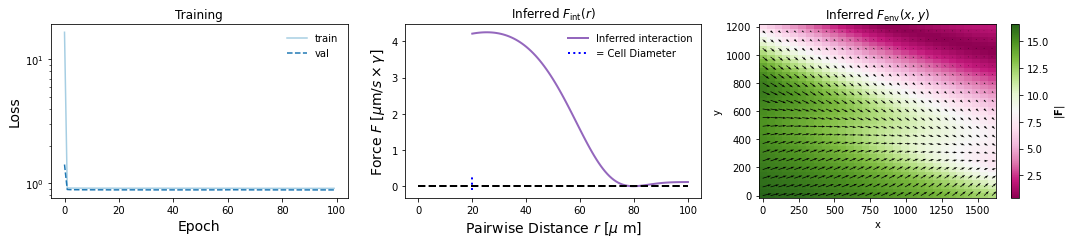

In [100]:
# Plot training history
fig,ax  = plt.subplots(1,3,figsize = (15,3.5))
scaleF = 1

ax[0].plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train')
ax[0].plot(history['val_loss'],color = clrs[1],linestyle = '--',label = 'val')
#ax[0].text(10,np.min(loaded_model_history_emt['train_loss'])*0.995+1,text1)
ax[0].legend(frameon = False)
ax[0].set_yscale('log')
ax[0].set_xlabel('Epoch',fontsize = 14)
ax[0].set_ylabel('Loss',fontsize = 14)
ax[1].plot(r_arr_plot,np.multiply(force_infer,scaleF),color = 'tab:purple',linestyle = '-',linewidth = 2,label = 'Inferred interaction')
#ax[1].plot(r_arr_plot,np.multiply(force_infer_100,scaleF),color = clrs[1],linestyle = '-',linewidth = 2,label = '100,100')
#ax[1].plot(r_arr_plot,np.multiply(force_infer_m100,scaleF),color = clrs[2],linestyle = '-',linewidth = 2,label = '-100,-100')
#ax[1].plot(r_arr_plot,np.multiply(force_infer_pep,scaleF),color ='tab:green',linestyle = '-',linewidth = 2,label = 'Peptide')
ax[1].set_xlabel(r'Pairwise Distance $r$ [$\mu$ m]',fontsize = 14)
ax[1].set_ylabel(r'Force $F$ [$\mu$m$/s \times \gamma$]',fontsize = 14)
ax[1].plot([0,r_cut],[0,0],color = 'black',linestyle = '--',linewidth = 2)
ax[1].plot([20,20],[-0.1,0.3],color = 'blue',linestyle = ':',linewidth = 2,label = "= Cell Diameter")
ax[1].legend(frameon = False)
#ax[1].set_ylim([-0.2,0.5])
pcm = ax[2].pcolormesh(X, Y, F_mag, shading='auto', cmap='PiYG')
cbar = fig.colorbar(pcm, ax=ax[2])
cbar.set_label(r'$|\mathbf{F}|$')

# === 3) Quiver on top ===
# (optional) downsample arrows so the plot isn’t too busy
sx = max(len(x_arr) // 20, 1)
sy = max(len(y_arr) // 20, 1)

ax[2].quiver(
    X[::sx, ::sy],
    Y[::sx, ::sy],
    F_env_infer[::sx, ::sy, 0],
    F_env_infer[::sx, ::sy, 1],
    color='k',  # arrows in black; background carries magnitude
    angles='xy',
    scale_units='xy',
    scale=None,   # or a number if you want to shrink arrows
    width=0.003
)

# === 4) Axes labels / ticks ===
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')
#ax[1].set_ylim([-0.1,0.1])
#ax[0].set_yscale('log')
ax[2].set_title(r'Inferred $F_{\mathrm{env}}(x,y)$')
ax[1].set_title(r'Inferred $F_{\mathrm{int}}(r)$')
ax[0].set_title(r'Training')
fig.tight_layout()
#fig.savefig(datasave+'F_env_infer.png',dpi=1000)


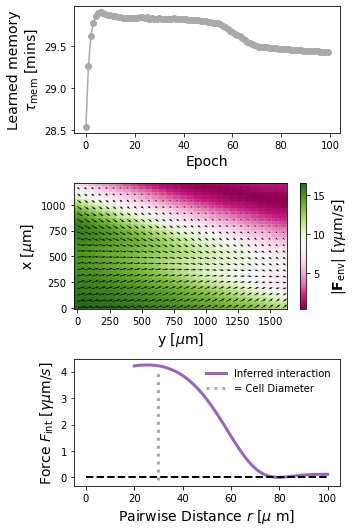

In [128]:
# plot loss
kappa0 = 0
fig,ax=plt.subplots(3,1,figsize = (5,7.5))

# ax[0].plot(history['train_loss'][2:],color = clrs[0],linestyle = '-',label = 'train',marker = 'o')
# ax[0].plot(history['val_loss'][2:],color = clrs[3],linestyle = '-',label = 'val',marker = 'o')
# ax[0].set_xlabel('Epoch',fontsize = 12)
# ax[0].set_ylabel('Loss',fontsize = 12)
# ax[0].set_yscale('log')
# ax[0].legend(fontsize = 12,frameon = False,loc = 'lower right')

ax[0].plot(np.multiply(history['tau_raw'],60),color = 'darkgrey',linestyle = '-',label = 'Learned memory',marker = 'o')
ax[0].set_xlabel('Epoch',fontsize = 14)
ax[0].set_ylabel("Learned memory\n"+r"$\tau_{\mathrm{mem}}$ [mins]",fontsize = 14)

pcm = ax[1].pcolormesh(X, Y, F_mag, shading='auto', cmap='PiYG')
cbar = fig.colorbar(pcm, ax=ax[1])
cbar.set_label(r'$|\mathbf{F_{\mathrm{env}}}|~[\gamma\mu\mathrm{m}/s]$',fontsize = 14)

# === 3) Quiver on top ===
# (optional) downsample arrows so the plot isn’t too busy
sx = max(len(x_arr) // 20, 1)
sy = max(len(y_arr) // 20, 1)

ax[1].quiver(
    X[::sx, ::sy],
    Y[::sx, ::sy],
    F_env_infer[::sx, ::sy, 0],
    F_env_infer[::sx, ::sy, 1],
    color='k',  # arrows in black; background carries magnitude
    angles='xy',
    scale_units='xy',
    scale=None,   # or a number if you want to shrink arrows
    width=0.003
)

# === 4) Axes labels / ticks ===
ax[1].set_xlabel('y [$\mu$m]',fontsize = 14)
ax[1].set_ylabel('x [$\mu$m]',fontsize = 14)

ax[2].plot(r_arr_plot,np.multiply(force_infer,scaleF),color = 'tab:purple',linestyle = '-',linewidth = 3,label = 'Inferred interaction')
ax[2].set_xlabel(r'Pairwise Distance $r$ [$\mu$ m]',fontsize = 14)
ax[2].set_ylabel(r'Force $F_{\mathrm{int}}$ [$\gamma\mu$m$/s$]',fontsize = 14)
ax[2].plot([0,r_cut],[0,0],color = 'black',linestyle = '--',linewidth = 2)
ax[2].plot([30,30],[-0.1,4],color = 'darkgrey',linestyle = ':',linewidth = 3,label = "= Cell Diameter")
ax[2].legend(frameon = False,loc = 'upper right')
fig.tight_layout()
#ax[1].legend(fontsize = 12,frameon = False)
fig.savefig(datasave+'Predictions.png',dpi=1000)



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


{'per_dim_var': array([0.8347502 , 0.93100417], dtype=float32), 'per_dim_std': array([0.91364664, 0.9648856 ], dtype=float32), 'overall_rms': 1.3296847343444824, 'num_samples': 13048, 'num_frames': 21, 'mean_residual': array([0.01591112, 0.04677294], dtype=float32), 'sum_residuals_sq_x': 10894.297, 'sum_residuals_sq_y': 12175.369}


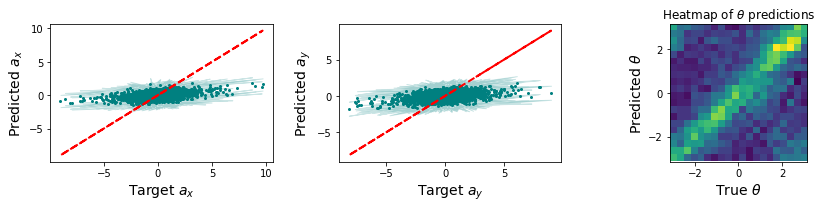

In [103]:
# visualise the y_pred vs y_true and put in a band for the noise on y_pred
evaluation = evaluate_model(model,val_data,verbose = False)

predictions = evaluation['predictions']
targets = evaluation['targets']
Overall_noise = estimate_noise_magnitude(model, val_data)
print(Overall_noise)

fig,ax = plt.subplots(1,3,figsize = (12,3))
ax[0].plot(targets[:, 0],predictions[:, 0],'o',color = 'teal',linestyle = '',markersize = 2)
ax[0].fill_between(targets[:, 0],predictions[:, 0]-Overall_noise['per_dim_std'][0],predictions[:, 0]+Overall_noise['per_dim_std'][0],color = 'teal',alpha = 0.2)
ax[0].plot(targets[:, 0],targets[:, 0],'r--',linewidth = 2)
ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = 'teal',linestyle = '',markersize = 2)
ax[1].fill_between(targets[:, 1],predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 1]+Overall_noise['per_dim_std'][1],color = 'teal',alpha = 0.2)
ax[1].plot(targets[:, 1],targets[:, 1],'r--',linewidth = 2)
ax[0].set_xlabel(r'Target $a_x$',fontsize = 14)
ax[0].set_ylabel(r'Predicted $a_x$',fontsize = 14)
ax[1].set_xlabel(r'Target $a_y$',fontsize = 14)
ax[1].set_ylabel(r'Predicted $a_y$',fontsize = 14)
ax[0].legend(frameon = False)
#predicted direction \theta vs true direction \theta
theta_pred = np.arctan2(predictions[:, 1],predictions[:, 0])
theta_true = np.arctan2(targets[:, 1],targets[:, 0])
theta_pred_upper = np.arctan2(predictions[:, 1]+Overall_noise['per_dim_std'][1],predictions[:, 0]-Overall_noise['per_dim_std'][0])
theta_pred_lower = np.arctan2(predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 0]+Overall_noise['per_dim_std'][0])
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
#mask out thetas from accelerations < 0.5
amin = 0
valid = a_mag > amin
theta_true_valid = theta_true[valid]
theta_pred_valid = theta_pred[valid]
theta_pred_upper_valid = theta_pred_upper[valid]
theta_pred_lower_valid = theta_pred_lower[valid]

# make this one a heatmap
heatmap, xedges, yedges = np.histogram2d(theta_true, theta_pred, bins=20)

ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[2].set_xlabel(r'True $\theta$',fontsize = 14)
ax[2].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[2].set_title(r'Heatmap of $\theta$ predictions')

# heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
# ax[3].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
# ax[3].set_xlabel(r'True $\theta$',fontsize = 14)
# ax[3].set_ylabel(r'Predicted $\theta$',fontsize = 14)
# ax[3].set_title(r'Heatmap of $\theta$ predictions')

fig.tight_layout()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


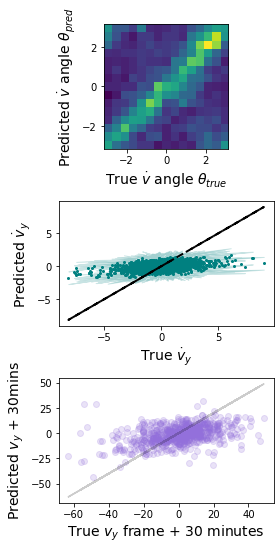

In [126]:
fig,ax=plt.subplots(3,1,figsize = (4,7.5))

ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[0].set_xlabel(r'True $\dot{v}$ angle $\theta_{true}$',fontsize = 14)
ax[0].set_ylabel(r'Predicted $\dot{v}$ angle $\theta_{pred}$',fontsize = 14)
ax[1].plot(targets[:, 1],predictions[:, 1],'o',color = 'teal',linestyle = '',markersize = 2)
ax[1].fill_between(targets[:, 1],predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 1]+Overall_noise['per_dim_std'][1],color = 'teal',alpha = 0.2)
ax[1].plot(targets[:, 1],targets[:, 1],color = 'black',linestyle = '--',linewidth = 2)
ax[1].set_xlabel(r'True $\dot{v}_y$',fontsize = 14)
ax[1].set_ylabel(r'Predicted $\dot{v}_y$',fontsize = 14)
ax[1].legend(frameon = False)
ax[2].scatter(vy_next_next_next,vy_next_next_next_pred_UD,color = 'mediumpurple',alpha = 0.2)
ax[2].plot(vy_next_next_next,vy_next_next_next,color = 'black',alpha = 0.2)
ax[2].set_xlabel(r'True $v_y$ frame + 30 minutes',fontsize = 14)
ax[2].set_ylabel(r'Predicted $v_y$ + 30mins',fontsize = 14)
fig.tight_layout()
fig.savefig(datasave+'PredictivePower.png',dpi=1000)


{'per_dim_var': array([0.8347502 , 0.93100417], dtype=float32), 'per_dim_std': array([0.91364664, 0.9648856 ], dtype=float32), 'overall_rms': 1.3296847343444824, 'num_samples': 13048, 'num_frames': 21, 'mean_residual': array([0.01591112, 0.04677294], dtype=float32), 'sum_residuals_sq_x': 10894.297, 'sum_residuals_sq_y': 12175.369}


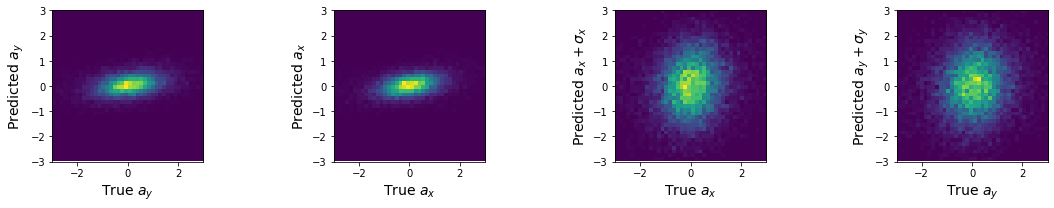

In [110]:
# visualise the y_pred vs y_true and put in a band for the noise on y_pred
evaluation = evaluate_model(model,val_data,verbose = False)
predictions = evaluation['predictions']
targets = evaluation['targets']
Overall_noise = estimate_noise_magnitude(model, val_data)
print(Overall_noise)

fig,ax = plt.subplots(1,4,figsize = (16,3))
# Compute common limits
vmin = -3 #min(targets[:, 1].min(), predictions[:, 1].min())
vmax = 3 #max(targets[:, 1].max(), predictions[:, 1].max())

# Square histogram
heatmap, xedges, yedges = np.histogram2d(
    targets[:, 1],
    predictions[:, 1],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[0].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[0].set_xlabel(r'True $a_y$', fontsize=14)
ax[0].set_ylabel(r'Predicted $a_y$', fontsize=14)
#ax[0].set_title(r'Heatmap of $a_y$ predictions')

# Compute common limits
vmin = -3 #min(targets[:, 0].min(), predictions[:, 0].min())
vmax = 3 #max(targets[:, 0].max(), predictions[:, 0].max())

# Square histogram
heatmap, xedges, yedges = np.histogram2d(
    targets[:, 0],
    predictions[:, 0],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[1].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[1].set_xlabel(r'True $a_x$', fontsize=14)
ax[1].set_ylabel(r'Predicted $a_x$', fontsize=14)
#ax[1].set_title(r'Heatmap of $a_x$ predictions')


# Square histogram
#make fake gaussian noise predictions

predictions_fake = np.zeros(predictions.shape)
for i in range(len(predictions)):
    predictions_fake[i,1] = predictions[i,1] + np.random.normal(0,Overall_noise['per_dim_std'][1])
    predictions_fake[i,0] = predictions[i,0] + np.random.normal(0,Overall_noise['per_dim_std'][0])
heatmap, xedges, yedges = np.histogram2d(
    targets[:, 0],
    predictions_fake[:, 0],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[2].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[2].set_xlabel(r'True $a_x$', fontsize=14)
ax[2].set_ylabel(r'Predicted $a_x +\sigma_x$', fontsize=14)
ax[2].set_xlim([-3,3])
ax[2].set_ylim([-3,3])
#ax[2].set_title(r'Heatmap of $a_x+\sigma_x$ predictions')


# Square histogram

heatmap, xedges, yedges = np.histogram2d(
    targets[:, 1],
    predictions_fake[:, 1],
    bins=40,
    range=[[vmin, vmax], [vmin, vmax]]
)

ax[3].imshow(
    heatmap.T,
    extent=[vmin, vmax, vmin, vmax],
    origin='lower',
    cmap='viridis',
    aspect='equal'
)

ax[3].set_xlabel(r'True $a_y$', fontsize=14)
ax[3].set_ylabel(r'Predicted $a_y +\sigma_y$', fontsize=14)
fig.tight_layout()


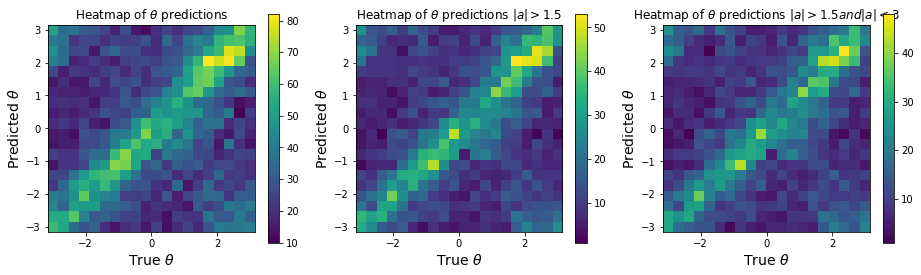

In [111]:
fig,ax = plt.subplots(1,3,figsize = (13,4))

theta_pred = np.arctan2(predictions[:, 1],predictions[:, 0])
theta_true = np.arctan2(targets[:, 1],targets[:, 0])
theta_pred_upper = np.arctan2(predictions[:, 1]+Overall_noise['per_dim_std'][1],predictions[:, 0]-Overall_noise['per_dim_std'][0])
theta_pred_lower = np.arctan2(predictions[:, 1]-Overall_noise['per_dim_std'][1],predictions[:, 0]+Overall_noise['per_dim_std'][0])
a_mag = np.sqrt(targets[:, 0]**2 + targets[:, 1]**2)
#mask out thetas from accelerations < 0.5
amin = 1.0
valid_1 = a_mag > amin
amax = 2.5
valid_2 = a_mag < amax
valid = valid_1 & valid_2

theta_true_valid = theta_true[valid_1]
theta_pred_valid = theta_pred[valid_1]
theta_pred_upper_valid = theta_pred_upper[valid_1]
theta_pred_lower_valid = theta_pred_lower[valid_1]

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[1].set_xlabel(r'True $\theta$',fontsize = 14)
ax[1].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[1].set_title(r'Heatmap of $\theta$ predictions $|a|>1.5$')
cbar = fig.colorbar(ax[1].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[1], shrink=0.9)

theta_true_valid = theta_true[valid]
theta_pred_valid = theta_pred[valid]
theta_pred_upper_valid = theta_pred_upper[valid]
theta_pred_lower_valid = theta_pred_lower[valid]

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[2].set_xlabel(r'True $\theta$',fontsize = 14)
ax[2].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[2].set_title(r'Heatmap of $\theta$ predictions $|a|>1.5 and |a|<3$')
cbar = fig.colorbar(ax[2].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[2], shrink=0.9)

heatmap, xedges, yedges = np.histogram2d(theta_true, theta_pred, bins=20)
ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis')
ax[0].set_xlabel(r'True $\theta$',fontsize = 14)
ax[0].set_ylabel(r'Predicted $\theta$',fontsize = 14)
ax[0].set_title(r'Heatmap of $\theta$ predictions')
cbar = fig.colorbar(ax[0].imshow(heatmap.T, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], origin='lower', cmap='viridis'), ax=ax[0], shrink=0.9)

fig.tight_layout()

In [112]:
ax = predictions[:, 0]
ay = predictions[:, 1]
ax_valid = ax[valid]
ay_valid = ay[valid]
sx = Overall_noise['per_dim_std'][0]
sy = Overall_noise['per_dim_std'][1]

sigma_a = np.sqrt(sx**2 + sy**2)

a_mag = np.sqrt(ax_valid**2 + ay_valid**2)

c = 5.0  # try 3, 5, 10
#valid = a_mag > c * sigma_a

den = ax_valid**2 + ay_valid**2
var_theta = (ay_valid**2 * sx**2 + ax_valid**2 * sy**2) / (den**2)

sigma_theta_global = np.sqrt(np.mean(var_theta))

print("kept fraction:", np.mean(valid))
print("Global sigma_theta (rad):", sigma_theta_global)
print("Global sigma_theta (deg):", np.degrees(sigma_theta_global))

dtheta = (theta_true_valid - theta_pred_valid + np.pi) % (2*np.pi) - np.pi  # wrap to [-pi,pi]
print(dtheta)
overall_theta_rms = np.sqrt(np.mean(dtheta*dtheta))
print("overall_theta_rms",overall_theta_rms)

targets_valid = targets #[valid]
ax = targets_valid[:,0]   # or predictions[:,0]
ay = targets_valid[:,1]   # or predictions[:,1]

sigma_x = Overall_noise['per_dim_std'][0]
sigma_y = Overall_noise['per_dim_std'][1]

den = ax**2 + ay**2
m = np.sqrt(den)

# mask out tiny magnitudes where direction is meaningless
m_min = 5.0 * np.sqrt(sigma_x**2 + sigma_y**2)   # simple SNR threshold
valid = m > m_min

theta = np.arctan2(ay, ax)

var_theta = (ay**2 * sigma_x**2 + ax**2 * sigma_y**2) / (den**2)
sigma_theta = np.sqrt(var_theta)

print(np.mean(sigma_theta))

kept fraction: 0.4160790925812385
Global sigma_theta (rad): 6.105675
Global sigma_theta (deg): 349.8294
[-0.1433351  -0.27320147  0.4797821  ... -1.0758059   1.0918214
  0.21656656]
overall_theta_rms 1.4350147
1.527945


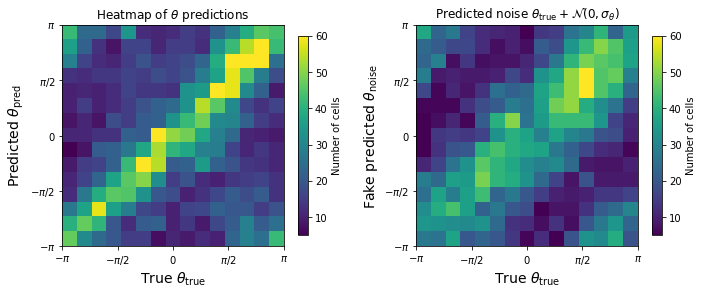

In [113]:
fig2,ax2 = plt.subplots(1,2,figsize = (10,4))

# calculate angular noise

heatmap, xedges, yedges = np.histogram2d(theta_true_valid, theta_pred_valid, bins=20)
#make some fake theta_pred from theta_true + gaussian noise. Noise taken from our estimate of the noise
theta_pred_fake = np.zeros(len(theta_true_valid))
for i in range(len(theta_true_valid)):
    theta_pred_fake[i] = theta_true_valid[i] + np.random.normal(0,overall_theta_rms) #theta_true[i] + 
    if theta_pred_fake[i] > np.pi:
        theta_pred_fake[i] = theta_pred_fake[i] - 2*np.pi
    elif theta_pred_fake[i] < -np.pi:
        theta_pred_fake[i] = theta_pred_fake[i] + 2*np.pi
heatmap_fake, xedges_fake, yedges_fake = np.histogram2d(theta_true_valid, theta_pred_fake, bins=20)
# 1) Use the SAME bin edges for both plots (critical)
bins = 15
# xmin, xmax = np.min(theta_true), np.max(theta_true)
# print(xmin, xmax)

# ymin = min(np.min(theta_pred), np.min(theta_pred_fake))
# ymax = max(np.max(theta_pred), np.max(theta_pred_fake))
# print(ymin, ymax)

xedges = np.linspace(-np.pi, np.pi, bins + 1)
yedges = np.linspace(-np.pi, np.pi, bins + 1)

heatmap, _, _      = np.histogram2d(theta_true_valid, theta_pred_valid,      bins=[xedges, yedges])
heatmap_fake, _, _ = np.histogram2d(theta_true_valid, theta_pred_fake, bins=[xedges, yedges])
heat_min = np.min(heatmap_fake)
heat_max = np.max(heatmap_fake)
# 2) Plot with identical extent + identical aspect
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]

im0 = ax2[0].imshow(heatmap.T, extent=extent, origin="lower",
                    cmap="viridis", aspect="equal",vmin = heat_min,vmax = heat_max)
im1 = ax2[1].imshow(heatmap_fake.T, extent=extent, origin="lower",
                    cmap="viridis", aspect="equal",vmin = heat_min,vmax = heat_max)

# 3) Force identical axis limits (belt + braces)
for ax in ax2:
    ax.set_xlim(xedges[0], xedges[-1])
    ax.set_ylim(yedges[0], yedges[-1])

# 4) One colorbar for both axes so layout stays aligned
cbar = fig2.colorbar(im0, ax=ax2[0], shrink=0.9)
cbar.set_label("Number of cells")
cbar = fig2.colorbar(im1, ax=ax2[1], shrink=0.9)
cbar.set_label("Number of cells")

# Labels/titles
ax2[0].set_xlabel(r"True $\theta_{\mathrm{{true}}}$", fontsize=14)
ax2[0].set_ylabel(r"Predicted $\theta_{\mathrm{{pred}}}$", fontsize=14)
ax2[0].set_title(r"Heatmap of $\theta$ predictions")

ax2[1].set_xlabel(r"True $\theta_{\mathrm{{true}}}$", fontsize=14)
ax2[1].set_ylabel(r"Fake predicted $\theta_{\mathrm{{noise}}}$", fontsize=14)
ax2[1].set_title(r"Predicted noise $\theta_{\mathrm{{true}}}+\mathcal{N}(0,\sigma_{\theta})$")
ax2[1].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[1].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[0].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])
ax2[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi],["$-\pi$","$-\pi/2$","$0$","$\pi/2$","$\pi$"])

fig2.tight_layout()

In [114]:
Data_Fine_UD = evaluate_model_frames(model,dataALL,verbose = False)


In [115]:
#print(dataALL[0]['y_std'].to_numpy())
array_ystd = np.array([d['y_std'] for d in dataALL])
print(array_ystd[0])


66.91766357421875


Acceleration–velocity correlation (a·v):
  mean(a·v) = -0.000013
  correlation (normalized) ≈ -0.002819
  -> Correlation is near zero; sign of gamma is poorly determined by the data.

Analyse predicted velocities

[-2.11608794e+00 -3.32205086e+00 -8.15241863e-01 -7.74557070e+00
  2.44127107e+00  5.24790255e+00 -3.73014006e+00  1.70209479e+00
  7.31699337e-01  4.26037109e+00  3.23034965e+00  6.36798128e+00
 -1.71003700e+00  6.74938831e+00 -5.10192428e-01  4.87182863e-01
  8.54215053e+00  2.62857632e+00 -6.99342419e+00  9.19359586e+00
  1.20671544e+00  2.55688199e+00 -3.25924293e+00  4.80862670e+00
  6.11936931e+00 -4.83011299e+00 -6.85413070e+00  4.53315038e+00
  4.04952481e+00  7.59281806e+00 -5.56282612e+00  6.82584556e+00
  1.52728701e+00  6.21762059e+00  3.88713041e+00  7.17008905e-01
  5.33261641e+00 -1.12189476e+00 -1.05524653e+00 -8.23418867e-01
  4.71133461e+00  4.41279202e+00  2.27755080e+00  7.07691610e+00
  5.69904958e+00  9.97165221e-02  3.61415670e-01 -2.78054447e-01
  6.56506600e+00  7.52200864e+00 -1.52075527e+00  1.87188620e+00
  1.32447977e+00  1.25949204e+00  5.70656582e+00 -4.56791764e+00
  1.37032597e+00 -1.70280602e+00  3.18440862e+00  5.47689531e+00
  3.86337740e+00  3.36049

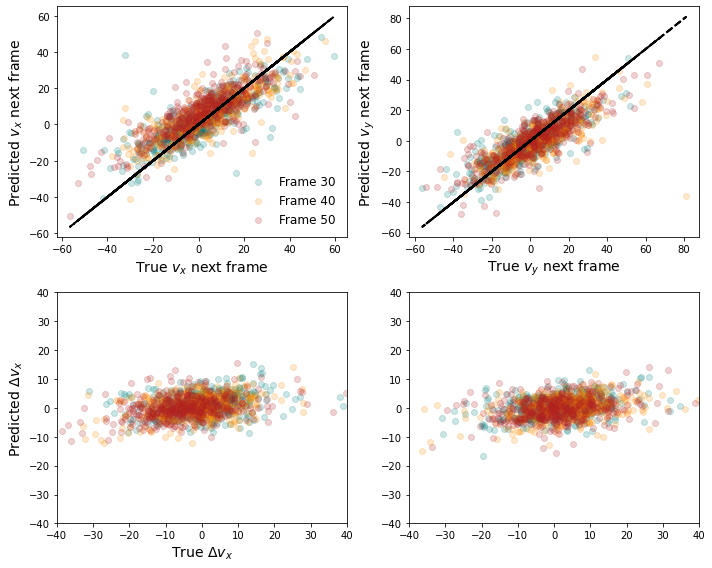

In [116]:
modelName = "UD"

if modelName == "Pers":
    Data_Fine = Data_Fine_Pers.copy()
elif modelName == "UD":
    Data_Fine = Data_Fine_UD.copy()
else:
    raise ValueError("Invalid model name")
colors = ['teal','darkorange','firebrick']
fig,ax = plt.subplots(2,2,figsize = (10,8))
frames = [30,40,50]
for ff, frame in enumerate(frames):
    frame_data = Data_Fine[Data_Fine["frame"] == frame].copy()
    frame_data_next = Data_Fine[Data_Fine["frame"] == frame + 1].copy()

    # Make sure IDs are plain numpy arrays
    Particle_IDs = frame_data["node_id"].to_numpy()
    Particle_IDs_next = frame_data_next["node_id"].to_numpy()

    vx = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy = np.full(len(Particle_IDs), np.nan, dtype=float)

    # Build a fast lookup for current frame
    cur = frame_data.set_index("node_id")
    nxt = frame_data_next.set_index("node_id")
    dvx = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvy = np.full(len(Particle_IDs), np.nan, dtype=float)

    for i, ID in enumerate(Particle_IDs):
        if ID in cur.index:
            vx[i] = float(cur.loc[ID, "vx"]) # vx and vy have not been normalised in any way
            vy[i] = float(cur.loc[ID, "vy"])
            # predicted increment (must be scalar)
            dvx[i] = float(cur.loc[ID, "pred_x"])*array_ystd[0]*dt # we need to put our predictions back into real units
            dvy[i] = float(cur.loc[ID, "pred_y"])*array_ystd[0]*dt # we need to put our predictions back into real units

    vx_next = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy_next = np.full(len(Particle_IDs), np.nan, dtype=float)

    true_dvx = np.full(len(Particle_IDs), np.nan, dtype=float)
    true_dvy = np.full(len(Particle_IDs), np.nan, dtype=float)

    if modelName == "Pers":
        vx_next_pred_Pers = np.full(len(Particle_IDs), np.nan, dtype=float)
        vy_next_pred_Pers = np.full(len(Particle_IDs), np.nan, dtype=float)
        pred_dvx_Pers = np.full(len(Particle_IDs), np.nan, dtype=float)
        pred_dvy_Pers = np.full(len(Particle_IDs), np.nan, dtype=float)
    elif modelName == "UD":
        pred_dvx_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
        pred_dvy_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
        vx_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
        vy_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    else:
        raise ValueError("Invalid model name")

    for i, ID in enumerate(Particle_IDs):
        if ID in nxt.index:
            # true next
            vx_next[i] = float(nxt.loc[ID, "vx"])
            vy_next[i] = float(nxt.loc[ID, "vy"])
        
            if i==0:
                print(dvx,dvy)
                print(vx[i],vy[i])

            true_dvx[i] = (vx_next[i] - vx[i])
            true_dvy[i] = (vy_next[i] - vy[i])
            if modelName == "Pers":
                pred_dvx_Pers[i] = dvx[i]
                pred_dvy_Pers[i] = dvy[i]
                vx_next_pred_Pers[i] = vx[i] + dvx[i]
                vy_next_pred_Pers[i] = vy[i] + dvy[i]  
            elif modelName == "UD":
                pred_dvx_UD[i] = dvx[i]
                pred_dvy_UD[i] = dvy[i]
                vx_next_pred_UD[i] = vx[i] + dvx[i]
                vy_next_pred_UD[i] = vy[i] + dvy[i]
            else:
                raise ValueError("Invalid model name")
            #pred_dvx_Pers[i] = dvx
            #pred_dvy_Pers[i] = dvy

    # plot the true and predicted velocities

    ax[0,0].scatter(vx_next,vx_next_pred_UD,color =colors[ff],alpha = 0.2,label  = "Frame "+str(frame))
    ax[0,0].plot(vx_next,vx_next,color = 'black',linestyle = '--',linewidth = 2)
    ax[0,1].scatter(vy_next,vy_next_pred_UD,color = colors[ff],alpha = 0.2)
    ax[0,1].plot(vy_next,vy_next,color = 'black',linestyle = '--',linewidth = 2)
    ax[1,0].scatter(true_dvx,pred_dvx_UD,color = colors[ff],alpha = 0.2)
    ax[1,1].scatter(true_dvy,pred_dvy_UD,color = colors[ff],alpha = 0.2)
ax[1,0].set_xlabel(r'True $\Delta v_x$',fontsize = 14)
ax[1,0].set_ylabel(r'Predicted $\Delta v_x$',fontsize = 14)
ax[0,0].set_xlabel(r'True $v_x$ next frame',fontsize = 14)
ax[0,0].set_ylabel(r'Predicted $v_x$ next frame',fontsize = 14)
ax[0,1].set_xlabel(r'True $v_y$ next frame',fontsize = 14)
ax[0,1].set_ylabel(r'Predicted $v_y$ next frame',fontsize = 14)
ax[1,0].set_ylim([-40,40])
ax[1,0].set_xlim([-40,40])
ax[1,1].set_ylim([-40,40])
ax[1,1].set_xlim([-40,40])
ax[0,0].legend(fontsize = 12,frameon = False,loc = 'lower right')
fig.tight_layout()

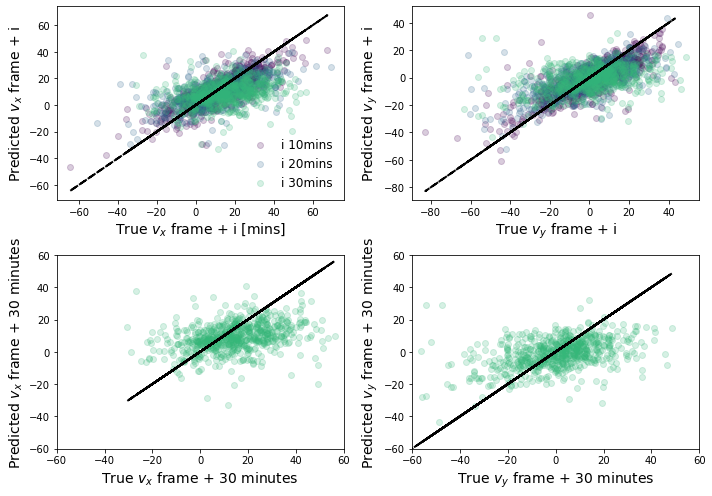

In [117]:
modelName = "UD"

if modelName == "Pers":
    Data_Fine = Data_Fine_Pers.copy()
elif modelName == "UD":
    Data_Fine = Data_Fine_UD.copy()
else:
    raise ValueError("Invalid model name")
colors = ['teal','darkorange','firebrick']
cmap = plt.cm.viridis
fig,ax = plt.subplots(2,2,figsize = (10,7))
frame = 100
iis_Adding = [1,2,3]
for ff, i_add in enumerate(iis_Adding):
    frame_data = Data_Fine[Data_Fine["frame"] == frame].copy()
    frame_data_next = Data_Fine[Data_Fine["frame"] == frame + iis_Adding[0]].copy()
    frame_data_next_next = Data_Fine[Data_Fine["frame"] == frame + iis_Adding[1]].copy()
    frame_data_next_next_next = Data_Fine[Data_Fine["frame"] == frame + iis_Adding[2]].copy()

    # Make sure IDs are plain numpy arrays
    Particle_IDs = frame_data["node_id"].to_numpy()
    Particle_IDs_next = frame_data_next["node_id"].to_numpy()
    Particle_IDs_next_next = frame_data_next_next["node_id"].to_numpy()
    Particle_IDs_next_next_next = frame_data_next_next_next["node_id"].to_numpy()

    vx = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy = np.full(len(Particle_IDs), np.nan, dtype=float)

    # Build a fast lookup for current frame
    cur = frame_data.set_index("node_id")
    nxt = frame_data_next.set_index("node_id")
    nxt_next = frame_data_next_next.set_index("node_id")
    nxt_next_next = frame_data_next_next_next.set_index("node_id")
    dvx_0 = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvy_0 = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvx_1 = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvy_1 = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvx_2 = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvy_2 = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvx_3 = np.full(len(Particle_IDs), np.nan, dtype=float)
    dvy_3 = np.full(len(Particle_IDs), np.nan, dtype=float)


    for i, ID in enumerate(Particle_IDs):
        if ID in cur.index:
            vx[i] = float(cur.loc[ID, "vx"]) # vx and vy have not been normalised in any way
            vy[i] = float(cur.loc[ID, "vy"])
            # predicted increment (must be scalar)
            dvx_0[i] = float(cur.loc[ID, "pred_x"])*array_ystd[0]*dt # we need to put our predictions back into real units
            dvy_0[i] = float(cur.loc[ID, "pred_y"])*array_ystd[0]*dt # we need to put our predictions back into real units

    vx_next = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy_next = np.full(len(Particle_IDs), np.nan, dtype=float)
    vx_next_next = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy_next_next = np.full(len(Particle_IDs), np.nan, dtype=float)
    vx_next_next_next = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy_next_next_next = np.full(len(Particle_IDs), np.nan, dtype=float)

    #true_dvx = np.full(len(Particle_IDs), np.nan, dtype=float)
    #true_dvy = np.full(len(Particle_IDs), np.nan, dtype=float)

    #pred_dvx_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    #pred_dvy_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    vx_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    vx_next_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy_next_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    vx_next_next_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)
    vy_next_next_next_pred_UD = np.full(len(Particle_IDs), np.nan, dtype=float)

    for i, ID in enumerate(Particle_IDs):
        if ID in nxt.index:
            # true next
            vx_next[i] = float(nxt.loc[ID, "vx"])
            vy_next[i] = float(nxt.loc[ID, "vy"])
            #true_dvx[i] = (vx_next[i] - vx[i])
            #true_dvy[i] = (vy_next[i] - vy[i])
            dvx_1[i] = float(nxt.loc[ID, "pred_x"])*array_ystd[0]*dt
            dvy_1[i] = float(nxt.loc[ID, "pred_y"])*array_ystd[0]*dt
            #pred_dvx_UD[i] = dvx_0[i]
            #pred_dvy_UD[i] = dvy_0[i]
            vx_next_pred_UD[i] = vx[i] + dvx_0[i]
            vy_next_pred_UD[i] = vy[i] + dvy_0[i]

        if ID in nxt_next.index:
            vx_next_next[i] = float(nxt_next.loc[ID, "vx"]) #true next next velocities
            vy_next_next[i] = float(nxt_next.loc[ID, "vy"])
            dvx_2[i] = float(nxt_next.loc[ID, "pred_x"])*array_ystd[0]*dt
            dvy_2[i] = float(nxt_next.loc[ID, "pred_y"])*array_ystd[0]*dt
            #pred_dvx_UD[i] = dvx_0[i] + dvx_1[i]
            #pred_dvy_UD[i] = dvy_0[i] + dvy_1[i]
            vx_next_next_pred_UD[i] = vx[i] + dvx_0[i] + dvx_1[i]
            vy_next_next_pred_UD[i] = vy[i] + dvy_0[i] + dvy_1[i]
        if ID in nxt_next_next.index:
            vx_next_next_next[i] = float(nxt_next_next.loc[ID, "vx"])
            vy_next_next_next[i] = float(nxt_next_next.loc[ID, "vy"])
            #pred_dvx_UD[i] = dvx_0[i] + dvx_1[i] + dvx_2[i]
            #pred_dvy_UD[i] = dvy_0[i] + dvy_1[i] + dvy_2[i]
            vx_next_next_next_pred_UD[i] = vx[i] + dvx_0[i] + dvx_1[i] + dvx_2[i]
            vy_next_next_next_pred_UD[i] = vy[i] + dvy_0[i] + dvy_1[i] + dvy_2[i]


    # plot the true and predicted velocities

ax[0,0].scatter(vx_next,vx_next_pred_UD,color =cmap(0/len(iis_Adding)),alpha = 0.2,label  = "i "+str(10) +"mins")
ax[0,0].scatter(vx_next_next,vx_next_next_pred_UD,color =cmap(1/len(iis_Adding)),alpha = 0.2,label  = "i "+str(20) +"mins")
ax[0,0].scatter(vx_next_next_next,vx_next_next_next_pred_UD,color =cmap(2/len(iis_Adding)),alpha = 0.2,label  = "i "+str(30) +"mins")
ax[1,0].scatter(vx_next_next_next,vx_next_next_next_pred_UD,color =cmap(2/len(iis_Adding)),alpha = 0.2,label  = "i "+str(30) +"mins")
ax[0,0].plot(vx_next,vx_next,color = 'black',linestyle = '--',linewidth = 2)
ax[1,0].plot(vx_next_next_next,vx_next_next_next,color = 'black',linestyle = '--',linewidth = 2)
ax[0,1].scatter(vy_next,vy_next_pred_UD,color = cmap(0/len(iis_Adding)),alpha = 0.2)
ax[0,1].scatter(vy_next_next,vy_next_next_pred_UD,color = cmap(1/len(iis_Adding)),alpha = 0.2)
ax[0,1].scatter(vy_next_next_next,vy_next_next_next_pred_UD,color = cmap(2/len(iis_Adding)),alpha = 0.2)
ax[1,1].scatter(vy_next_next_next,vy_next_next_next_pred_UD,color = cmap(2/len(iis_Adding)),alpha = 0.2)

ax[0,1].plot(vy_next,vy_next,color = 'black',linestyle = '--',linewidth = 2)
ax[1,1].plot(vy_next_next_next,vy_next_next_next,color = 'black',linestyle = '--',linewidth = 2)
# ax[1,0].scatter(true_dvx,pred_dvx_UD,color = cmap(ff/len(frames)),alpha = 0.2)
# ax[1,1].scatter(true_dvy,pred_dvy_UD,color = cmap(ff/len(frames)),alpha = 0.2)
ax[1,0].set_xlabel(r'True $v_x$ frame + 30 minutes',fontsize = 14)
ax[1,0].set_ylabel(r'Predicted $v_x$ frame + 30 minutes',fontsize = 14)
ax[1,1].set_xlabel(r'True $v_y$ frame + 30 minutes',fontsize = 14)
ax[1,1].set_ylabel(r'Predicted $v_y$ frame + 30 minutes',fontsize = 14)
ax[0,0].set_xlabel(r'True $v_x$ frame + i [mins]',fontsize = 14)
ax[0,0].set_ylabel(r'Predicted $v_x$ frame + i',fontsize = 14)
ax[0,1].set_xlabel(r'True $v_y$ frame + i',fontsize = 14)
ax[0,1].set_ylabel(r'Predicted $v_y$ frame + i',fontsize = 14)
# ax[2,1].plot(vy_next_next_next,vy_next_next_next,color = 'black',linestyle = '--',linewidth = 2)
# ax[2,0].plot(vx_next_next_next,vx_next_next_next,color = 'black',linestyle = '--',linewidth = 2)
# ax[2,1].scatter(vy_next_next_next,vy,color = cmap(2/len(iis_Adding)),alpha = 0.2)
# ax[2,0].scatter(vx_next_next_next,vx,color = cmap(2/len(iis_Adding)),alpha = 0.2)
# ax[2,0].set_xlabel(r'True $v_x$ frame + 30 minutes',fontsize = 14)
# ax[2,0].set_ylabel(r'True $v_x$ frame',fontsize = 14)
# ax[2,1].set_xlabel(r'True $v_y$ frame + 30 minutes',fontsize = 14)
# ax[2,1].set_ylabel(r'True $v_y$ frame',fontsize = 14)
ax[1,0].set_ylim([-60,60])
ax[1,0].set_xlim([-60,60])
ax[1,1].set_ylim([-60,60])
ax[1,1].set_xlim([-60,60])
ax[0,0].legend(fontsize = 12,frameon = False,loc = 'lower right')
fig.tight_layout()

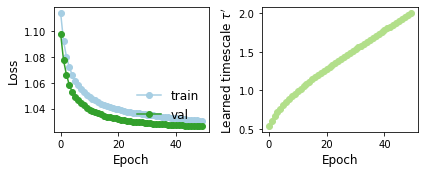

In [10]:
# plot loss
kappa0 = 0
fig,ax=plt.subplots(1,2,figsize = (6,2.5))

ax[0].plot(history['train_loss'],color = clrs[0],linestyle = '-',label = 'train',marker = 'o')
ax[0].plot(history['val_loss'],color = clrs[3],linestyle = '-',label = 'val',marker = 'o')
ax[0].set_xlabel('Epoch',fontsize = 12)
ax[0].set_ylabel('Loss',fontsize = 12)
ax[0].legend(fontsize = 12,frameon = False,loc = 'lower right')

ax[1].plot(history['tau_raw'],color = clrs[2],linestyle = '-',label = 'Learned memory',marker = 'o')
ax[1].set_xlabel('Epoch',fontsize = 12)
ax[1].set_ylabel(r"Learned timescale $\tau'$",fontsize = 12)
#ax[1].legend(fontsize = 12,frameon = False)
fig.tight_layout()